# Ciencia de Datos - Parcial 2

##Objetivo

Generar un conjunto de $N$ datos en $\mathbb{R}^5$ con dos clases, de manera que:

* Un modelo de **Regresión Logística** obtenga un **accuracy cercano a 0.60**.
* Un modelo basado en **Random Forest** alcance una **ROC AUC cercana a 0.85**.
* Un modelo **SVM con kernel** supere en desempeño al Random Forest.

Además, se debe explicar y justificar el diseño del dataset mediante argumentos teóricos y visualizaciones.

## Parámetros

* Utilizar:

$$
N = \frac{\text{DNI}}{100}
$$


# Trabajo Realizado

Este trabajo consiste en diseñar una geometría de datos que produzca el comportamiento solicitado para cada algoritmo.




A partir de esto me surge la siguiente pregunta:

**¿Qué tipo de geometría debería darle a las dos clases en $\mathbb{R}^5$ para que la Regresión Logística tenga dificultades para clasificarlas, mientras que un Random Forest pueda aprovechar patrones no lineales y un SVM consiga un rendimiento aún mejor?**

*Si los datos son linealmente separables, la Regresión Logística (LR) tendrá un buen Accuracy. Para reducir eso, necesitamos no-linealidad y solapamiento.*

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.metrics import roc_curve

#FIJAMOS SEMILLA
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


#DEFINIMOS TAMAÑO DE DATASET
N = 42815898 // 100
N_clase = N // 2

print(f"Número de muestras (N): {N}")
print(f"Número de muestras por clase (N/2): {N_clase}")

Número de muestras (N): 428158
Número de muestras por clase (N/2): 214079


Al hacer `N // 2` estoy creando un un **Dataset Balanceado**
Es decir, la probabilidad a priori de las clases es exactamente:

$$ P(Y=0) = 0.5 \quad \text{y} \quad P(Y=1) = 0.5$$

# **Densidades condicionales de Clase $P(\mathbf{x}|Y)$**

## Dimensión $X_1$: Densidades Condicionales Lineales

Definimos las distribuciones condicionales para la primera dimensión como:

$$P(X_1 | Y=0) \sim \mathcal{N}(-0.25, 1.0)$$$$P(X_1 | Y=1) \sim \mathcal{N}(0.25, 1.0)$$

In [ ]:
# Componente Lineal (X1)
X1_0 = np.random.normal(-0.25, 1.0, N_clase)
X1_1 = np.random.normal(0.25, 1.0, N_clase)

¿Por qué ets elección?

*La idea fue que la Regresión Logística tuviera algo de información , pero no la suficiente como para separar bien las clases. Para eso, las medias están apenas separadas.*

*Como la diferencia es pequeña , existe mucho solapamiento entre ambas clases. Esto hace que no haya una frontera lineal clara y limita el rendimiento de la Regresión Logística.*

## Dimensiones $X_2$ y $X_3$: Concéntrica No Lineal

Para generar esta parte, construí dos anillos concéntricos en el plano formado por las variables $X_2$ y $X_3$.



1.   Primero generé un ángulo $\theta$ aleatorio entre $0$ y $2\pi$ .
2.   Generé un radio $r$ distinto según la clase: La Clase 0 se concentra en un radio chico ($\mu = 2.0$) y la Clase 1 en un radio más grande y externo ($\mu = 3.8$).
3.   Transformé esas coordenadas polares $(r, \theta)$ a coordenadas cartesianas $(X_2, X_3)$ usando identidades trigonométricas: $X_2 = r \cos(\theta)$ y $X_3 = r \sin(\theta)$.

In [ ]:
#Componente Radial (X2, X3)
theta_0 = np.random.uniform(0, 2*np.pi, N_clase)
r_0 = np.random.normal(2.0, 1.0, N_clase) # Radio de la clase 0
X2_0 = r_0 * np.cos(theta_0)
X3_0 = r_0 * np.sin(theta_0)

theta_1 = np.random.uniform(0, 2*np.pi, N_clase)
r_1 = np.random.normal(3.8, 1.0, N_clase)  # Radio de la clase 1 (más afuera)
X2_1 = r_1 * np.cos(theta_1)
X3_1 = r_1 * np.sin(theta_1)


¿Por qué esta elección?

*La separación entre las clases en este espacio tiene forma circular: una clase queda concentrada en el anillo interno y la otra en el anillo externo.*

*Se eligió esta estructura porque la Regresión Logística, al buscar una frontera lineal, no puede separar correctamente dos clases distribuidas en círculos concéntricos. Cualquier recta que trace va a atravesar ambas clases y generar muchos errores.*

*En cambio, Random Forest puede aproximar esta frontera mediante múltiples particiones del espacio, capturando parte del patrón. Por su parte, el SVM con kernel RBF está especialmente preparado para detectar este tipo de relaciones no lineales, por lo que puede modelar la frontera circular de mejor manera.*


## Dimensiones $X_4$ y $X_5$ : Ruido

Las últimas dos dimensiones corresponden a ruido gaussiano , idéntico para ambas clases:

$$P(X_4|Y=0) = P(X_4|Y=1) \sim \mathcal{N}(0, 1.5^2)$$$$P(X_5|Y=0) = P(X_5|Y=1) \sim \mathcal{N}(0, 1.5^2)$$

In [ ]:
# Ruido (X4, X5)
X4_0, X5_0 = np.random.normal(0, 1.5, N_clase), np.random.normal(0, 1.5, N_clase)
X4_1, X5_1 = np.random.normal(0, 1.5, N_clase), np.random.normal(0, 1.5, N_clase)


# **Armado del dataset y división de los datos**



Una vez generadas las cinco variables, las uní en una única matriz de características $X$ y construí el vector de etiquetas $y$, que indica a qué clase pertenece cada observación.

Luego dividí el dataset en un conjunto de entrenamiento (80%) y otro de prueba (20%).

In [ ]:

X_0 = np.column_stack((X1_0, X2_0, X3_0, X4_0, X5_0))
X_1 = np.column_stack((X1_1, X2_1, X3_1, X4_1, X5_1))

y_0 = np.zeros(N_clase)
y_1 = np.ones(N_clase)

X = np.vstack((X_0, X_1))
y = np.concatenate((y_0, y_1))

#Division de datos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

# **Visualizacion de datos**

Debido a las dimensiones del dataset un gráfico de dispersión con todos los datos generó una solapamiento grande entre los datos, ya que no se podria aprecia como estaban distribidos, por eso se extrae unasubmuetra de tamaño de $2.000$ observaciones

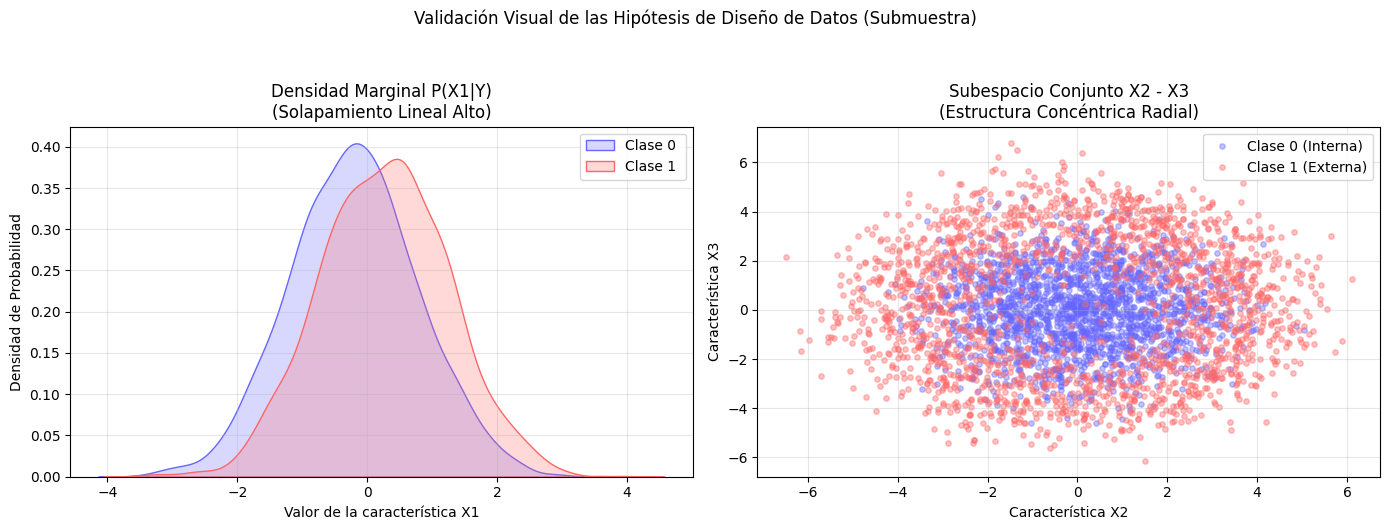

In [ ]:
#Definimos un tamaño de muestra pequeño
N_muestra = 2000  # puntos por clase

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.kdeplot(X1_0[:N_muestra], fill=True, color=plt.cm.bwr(0.2), label='Clase 0 ')
sns.kdeplot(X1_1[:N_muestra], fill=True, color=plt.cm.bwr(0.8), label='Clase 1 ')
plt.title('Densidad Marginal P(X1|Y)\n(Solapamiento Lineal Alto)')
plt.xlabel('Valor de la característica X1')
plt.ylabel('Densidad de Probabilidad')
plt.legend()
plt.grid(True, alpha=0.3)


plt.subplot(1, 2, 2)
plt.scatter(X2_0[:N_muestra], X3_0[:N_muestra], alpha=0.4, color=plt.cm.bwr(0.2), label='Clase 0 (Interna)', s=15)
plt.scatter(X2_1[:N_muestra], X3_1[:N_muestra], alpha=0.4, color=plt.cm.bwr(0.8), label='Clase 1 (Externa)', s=15)
plt.title('Subespacio Conjunto X2 - X3\n(Estructura Concéntrica Radial)')
plt.xlabel('Característica X2')
plt.ylabel('Característica X3')
plt.legend()
plt.grid(True, alpha=0.3)


plt.suptitle("Validación Visual de las Hipótesis de Diseño de Datos (Submuestra)", y=1.05)
plt.tight_layout()
plt.show()

*En el gráfico de la izquierda ($X_1$) se puede ver que las distribuciones de ambas clases se superponen mucho. Aunque existe una pequeña diferencia entre ellas, no es suficiente para separarlas claramente, por lo que la Regresión Logística tiene información limitada para clasificar correctamente.*

E*n el gráfico de la derecha ($X_2$ vs $X_3$) aparece la estructura principal del dataset. La Clase 0 queda concentrada cerca del centro, mientras que la Clase 1 forma un anillo a su alrededor. Esta relación no lineal es la que pueden aprovechar mucho mejor Random Forest y SVM.*


<Figure size 640x480 with 0 Axes>

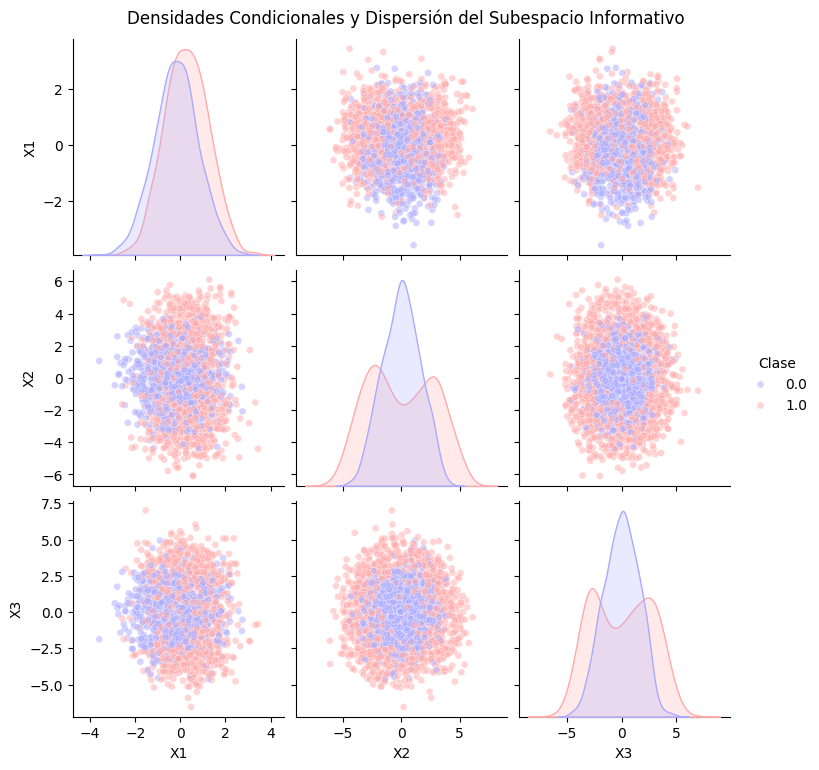

In [ ]:
df_features = pd.DataFrame(X[:, :5], columns=[f'X{i+1}' for i in range(5)])
df_features['Clase'] = y


df_visualizacion = (df_features
                    .sample(n=N_muestra, random_state=RANDOM_STATE)
                    .sample(frac=1, random_state=RANDOM_STATE)
                    .reset_index(drop=True))

#Construcción de la matriz de gráficos de dispersión y densidades condicionales
plt.figure()
sns.pairplot(
    df_visualizacion,
    vars=['X1', 'X2', 'X3'],
    hue='Clase',
    diag_kind='kde',
    palette='bwr',
    plot_kws={'alpha': 0.5, 's': 25}
)

plt.suptitle("Densidades Condicionales y Dispersión del Subespacio Informativo", y=1.02)
plt.show()

***En la Diagonal** : En $X_1$ se ve un solapamiento de las clases. En las variables $X_2$ y $X_3$, la Clase 1 muestra dos picos en su distribución. Esto ocurre porque los puntos que forman el anillo, al proyectarse sobre un único eje, tienden a concentrarse más en los extremos que en el centro.*


***Fuera de la Diagonal**: La interacción conjunta en el plano $X_2 - X_3$ confirma que la frontera óptima es una circunferencia.*

# **Modelados**

*La Regresión Logística intenta separar las clases mediante una frontera lineal. El problema es que la estructura formada por $X_2$ y $X_3$ tiene una separación circular, algo que una recta no puede representar correctamente.*

*Por eso, el modelo termina dependiendo principalmente de $X_1$, donde las clases presentan mucho solapamiento. Como consecuencia, su capacidad de clasificación queda limitada.*


In [ ]:
## REGRESIÓN LOGÍSTICA
lr = LogisticRegression()
lr.fit(X_train, y_train)
lr_preds = lr.predict(X_test)
lr_acc = accuracy_score(y_test, lr_preds)

*Un árbol de decisión divide el espacio de datos realizando cortes sucesivos sobre las variables. En cada paso busca una variable y un punto de corte que permitan separar mejor las clases.*

*Como estos cortes siempre son paralelos a los ejes, las fronteras que genera son rectas (o, en dimensiones mayores, hiperplanos ortogonales). Por eso, un árbol no puede representar directamente una frontera curva, aunque puede aproximarla combinando muchos cortes consecutivos.*


**Construcción del Random Forest**

Al utilizar `n_estimators=100`, el modelo genera 100 árboles de decisión distintos. Cada árbol se entrena con una muestra aleatoria de los datos de entrenamiento y en cada división considera solo un subconjunto aleatorio de variables.

La idea es que los árboles sean diferentes entre sí. Luego, en lugar de quedarse con la predicción de un único árbol, el Random Forest combina las predicciones de todos promediando sus resultados.

La probabilidad final asignada a una observación se obtiene como el promedio de las probabilidades estimadas por cada árbol:

$$
P(Y=1 \mid \mathbf{x}) = \frac{1}{100}\sum_{b=1}^{100} P_b(Y=1 \mid \mathbf{x})
$$

Al fijar `max_depth = 2`, cada árbol queda limitado a realizar muy pocos cortes sobre los datos. Como la separación entre las clases tiene una forma circular, serían necesarios muchos más cortes para aproximar correctamente esa frontera.

Esta restricción fue intencional para cumplir con  la consigna. Si los árboles fueran más profundos, el Random Forest podría capturar mucho mejor la estructura del dataset y alcanzar métricas más altas de las buscadas.

In [ ]:
## RANDOM FOREST
rf = RandomForestClassifier(n_estimators=100, max_depth=2, random_state=RANDOM_STATE)
rf.fit(X_train, y_train)
rf_probs = rf.predict_proba(X_test)[:, 1]
rf_auc = roc_auc_score(y_test, rf_probs)

Para el SVM utilicé `kernel='rbf'`:

$$
K(\mathbf{x}, \mathbf{x'}) = \exp\left(-\gamma |\mathbf{x} - \mathbf{x'}|^2\right)
$$


Hiperparámetros:

* **`gamma='scale'`**: Esto permite que el SVM se adapte de forma perfecta al tamaño del círculo de los datos.

* **`C=1.0`**: controla el equilibrio entre ajustar correctamente los datos de entrenamiento y evitar sobreajuste.


In [ ]:
## SVM (KERNEL RBF)
svm = SVC(kernel='rbf', probability=True, C=1.0, gamma='scale', random_state=RANDOM_STATE)
svm.fit(X_train, y_train)
svm_probs = svm.predict_proba(X_test)[:, 1]
svm_auc = roc_auc_score(y_test, svm_probs)

# **Visualización de las métricas**

In [ ]:

resumen = pd.DataFrame({
    'Modelo': ['Regresión Logística', 'Random Forest', 'SVM (RBF)'],
    'Métrica Principal': ['Accuracy', 'ROC AUC', 'ROC AUC'],
    'Valor Obtenido': [lr_acc, rf_auc, svm_auc]
})

print("       RESUMEN DE MÉTRICAS FINALES      ")
print(resumen.to_string(index=False))

       RESUMEN DE MÉTRICAS FINALES      
             Modelo Métrica Principal  Valor Obtenido
Regresión Logística          Accuracy        0.596740
      Random Forest           ROC AUC        0.855691
          SVM (RBF)           ROC AUC        0.903607


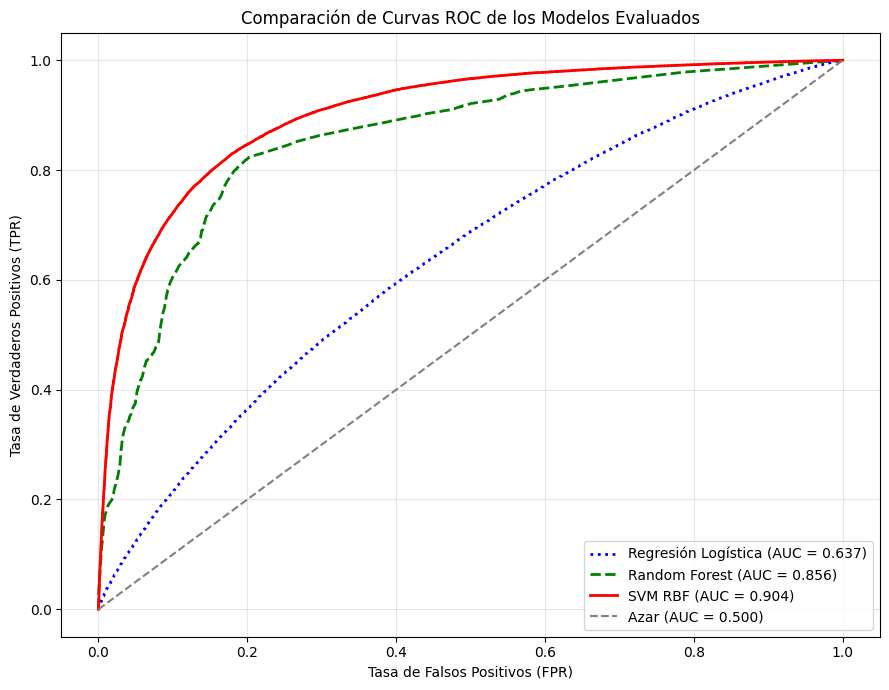

In [ ]:
# Necesitamos las probabilidades de la Regresión Logística
lr_probs = lr.predict_proba(X_test)[:, 1]
lr_auc = roc_auc_score(y_test, lr_probs)

# Cálculo de las tasas de Falsos Positivos (FPR) y Verdaderos Positivos (TPR)
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_probs)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_probs)
fpr_svm, tpr_svm, _ = roc_curve(y_test, svm_probs)


plt.figure(figsize=(9, 7))
plt.plot(fpr_lr, tpr_lr, color='blue', linestyle=':', linewidth=2,
         label=f'Regresión Logística (AUC = {lr_auc:.3f})')
plt.plot(fpr_rf, tpr_rf, color='green', linestyle='--', linewidth=2,
         label=f'Random Forest (AUC = {rf_auc:.3f})')
plt.plot(fpr_svm, tpr_svm, color='red', linestyle='-', linewidth=2,
         label=f'SVM RBF (AUC = {svm_auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Azar (AUC = 0.500)')


plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Comparación de Curvas ROC de los Modelos Evaluados')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# **Conclusión**

*El objetivo de este trabajo fue diseñar una geometría de los datos capaz de generar el comportamiento esperado para cada modelo.*

*Durante el desarrollo del trabajo se analizaron diferentes alternativas, variando tanto la geometría de los datos como algunos hiperparámetros.*

*Finalmente, se construyó un dataset a partir de una combinación de una dimensión con mucho solapamiento ($X_1$), una geometría de anillos concéntricos en el plano $X_2$-$X_3$ y variables de ruido ($X_4$ y $X_5$).*

*Esta geometría permitió que la **Regresión Logística** quedara limitada por su incapacidad para modelar fronteras de decisión no lineales y dependiera principalmente de $X_1$, donde existe un fuerte solapamiento entre clases. En cambio, el **Random Forest** y el **SVM** pudieron aprovechar la estructura no lineal presente en los datos. Además, se ajustaron algunos hiperparámetros, como la profundidad del Random Forest, para aproximar las métricas solicitadas. Como resultado, el **SVM** logró el mejor desempeño, seguido por el **Random Forest** y, finalmente, la **Regresión Logística**.*
